# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: Group6

Created by Brian Luong (016187743), Andrew Chen (018035679), Joshua Layokun (016336281)

Last updated: 3/24/2026

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
import numpy as np
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px

games_data = "/content/drive/MyDrive/CS133/Video_Games_Sales_as_at_22_Dec_2016.csv"
games = pd.read_csv(games_data,
                      na_values=['tbd'],
                      engine='python',
                     )
games["Log_Global_Sales"] = np.log1p(games["Global_Sales"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def configure_plotly_browser_state():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              plotly: 'https://cdn.plot.ly/plotly-latest.min.js?noext',
            },
          });
        </script>
        '''))

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

Answer: Our data had virtually no issues of incorrect null values or inconsistent data. The only thing that needed to be changed was including "tbd" as a null value.

In [ ]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              16717 non-null  object 
 1   Platform          16719 non-null  object 
 2   Year_of_Release   16450 non-null  float64
 3   Genre             16717 non-null  object 
 4   Publisher         16665 non-null  object 
 5   NA_Sales          16719 non-null  float64
 6   EU_Sales          16719 non-null  float64
 7   JP_Sales          16719 non-null  float64
 8   Other_Sales       16719 non-null  float64
 9   Global_Sales      16719 non-null  float64
 10  Critic_Score      8137 non-null   float64
 11  Critic_Count      8137 non-null   float64
 12  User_Score        7590 non-null   float64
 13  User_Count        7590 non-null   float64
 14  Developer         10096 non-null  object 
 15  Rating            9950 non-null   object 
 16  Log_Global_Sales  16719 non-null  float6

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

Question: How does Critic Score compare to the User Scores of games.

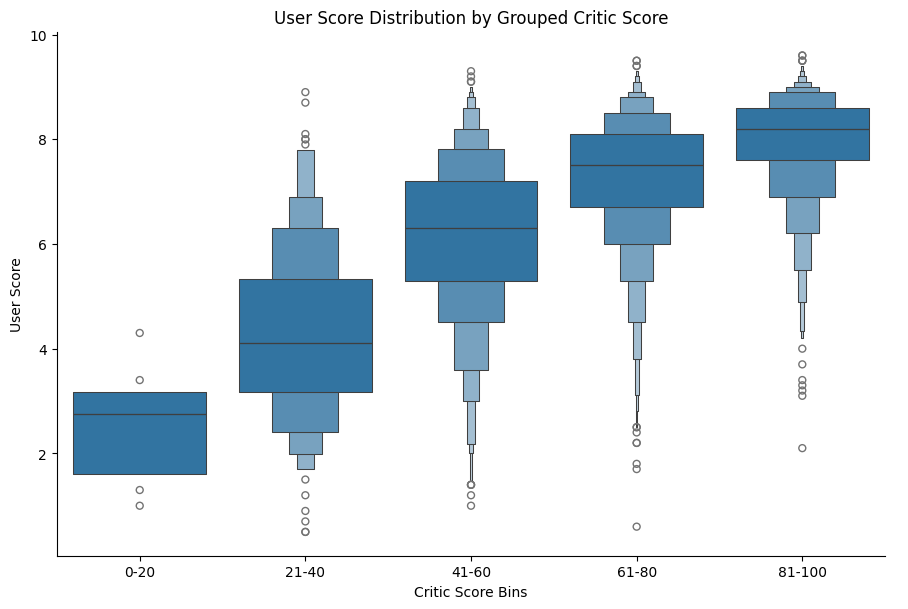

In [ ]:
# Your code here . . .
games['Critic_Score_Binned'] = pd.cut(games['Critic_Score'], bins=[0, 20, 40, 60, 80, 100], labels=['0-20', '21-40', '41-60', '61-80', '81-100'], right=False)
sns.catplot(
    data=games,
    x="Critic_Score_Binned",
    y="User_Score",
    kind="boxen",
    height=6,
    aspect=1.5
)
plt.title('User Score Distribution by Grouped Critic Score')
plt.xlabel('Critic Score Bins')
plt.ylabel('User Score')
plt.show()

### Q3: Come up with a another unique question. This question must use map() or apply()

The Critic Scores and User Scores do not operate on the same scale. Transform one of the columns so that the scoring is standardized.

In [ ]:
# Your code here . . .
games.Critic_Score = games.Critic_Score.apply(lambda x: x/10)
games.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Log_Global_Sales,Critic_Score_Binned
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,7.6,51.0,8.0,322.0,Nintendo,E,4.425206,61-80
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN,3.719409,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,8.2,73.0,8.3,709.0,Nintendo,E,3.597860,81-100
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,8.0,73.0,8.0,192.0,Nintendo,E,3.519573,81-100
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN,3.477232,NaN


### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

Question: Is there a significant correlation between critic scores and global sales?

In [ ]:
configure_plotly_browser_state()

plot_games = games.dropna(subset=["Critic_Score", "Global_Sales", "Name"]).copy()
plot_games["Log_Global_Sales"] = np.log1p(plot_games["Global_Sales"])

trace = go.Scatter(
    x=plot_games["Critic_Score"],
    y=plot_games["Log_Global_Sales"],
    mode="markers",
    name="Games",
    marker=dict(color='rgba(94, 29, 211, 0.5)'),
    text=plot_games["Name"]
)

layout = dict(
    title="Critic Score vs log(1 + Global Sales)",
    xaxis=dict(title="Critic Score", ticklen=5, zeroline=False),
    yaxis=dict(title="log(1 + Global Sales)", ticklen=5, zeroline=False)
)

fig = dict(data=[trace], layout=layout)
iplot(fig)

The interaction strengthens what we want to communicate by allowing users to explore global sales in relation to critic score using differnt tools. This includes tools like zoom, pan, hover, and focusing on specific sections which allows for more in depth analysis.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

An additional dataset we could use to help strengthen our data could be one for the marketing/advertising data how how much each game spent on their promotion.
The pseudocode of what that would like is:

In [ ]:
# Your code here . . .
# marketing = load_csv("marketing_budget.csv")

# merged_df = merge(
#     games,
#     marketing,
#     left_on=["Name", "Year"],
#     right_on=["Name", "Year"],
#     how="left"
# )

# merged_df["Name"] = merged_df["Name"].str.lower().str.strip()
# merged_df = merged_df.drop_duplicates(subset=["Name", "Platform", "Year"])
# merged_df["Marketing_Budget"] = pd.to_numeric(merged_df["Marketing_Budget"], errors="coerce")
# merged_df["Global_Sales"] = pd.to_numeric(merged_df["Global_Sales"], errors="coerce")
# merged_df = merged_df.dropna(subset=["Global_Sales"])